# TP Bloque 12 — Q-Learning en GridWorld

**Fundamentos e Historia de la IA — Aprendizaje por Refuerzo**

Este notebook está completo. La tarea no es reescribir Q-Learning desde cero, sino ejecutar, observar, modificar hiperparámetros e interpretar cómo aprende el agente.

Idea central del bloque:

> epsilon-greedy elige la acción. El entorno devuelve recompensa y nuevo estado. Q-Learning actualiza la estimación de valor de esa acción.

## 1. El ciclo que vamos a identificar

En cada paso del entrenamiento ocurre:

1. El agente está en un estado `s`.
2. `epsilon-greedy` elige una acción `a`.
3. El entorno ejecuta la acción y devuelve recompensa `r` y nuevo estado `s'`.
4. Q-Learning actualiza `Q(s,a)`.
5. Se repite.

Durante la práctica, identifiquen estas partes en el código.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, List

State = Tuple[int, int]

ACTIONS = {
    0: (-1, 0),  # arriba
    1: (1, 0),   # abajo
    2: (0, -1),  # izquierda
    3: (0, 1),   # derecha
}
ACTION_SYMBOLS = {0: "↑", 1: "↓", 2: "←", 3: "→"}

## 2. Entorno GridWorld

El entorno define estados, acciones, recompensas, obstáculo, meta y trampa.

In [2]:
@dataclass
class GridWorld:
    rows: int = 5
    cols: int = 5
    start: State = (0, 0)
    goal: State = (4, 4)
    trap: State = (3, 4)
    walls: Tuple[State, ...] = ((2, 2),)
    step_reward: float = -1.0
    goal_reward: float = 10.0
    trap_reward: float = -10.0
    max_steps: int = 100

    def reset(self) -> State:
        return self.start

    def state_to_index(self, state: State) -> int:
        return state[0] * self.cols + state[1]

    def index_to_state(self, idx: int) -> State:
        return divmod(idx, self.cols)

    @property
    def n_states(self) -> int:
        return self.rows * self.cols

    @property
    def n_actions(self) -> int:
        return len(ACTIONS)

    def in_bounds(self, state: State) -> bool:
        r, c = state
        return 0 <= r < self.rows and 0 <= c < self.cols

    def is_wall(self, state: State) -> bool:
        return state in self.walls

    def is_terminal(self, state: State) -> bool:
        return state == self.goal or state == self.trap

    def step(self, state: State, action: int):
        """Ejecuta una acción y devuelve: nuevo_estado, recompensa, terminado."""
        if self.is_terminal(state):
            return state, 0.0, True

        dr, dc = ACTIONS[action]
        candidate = (state[0] + dr, state[1] + dc)

        # Si choca contra pared o borde, se queda en el mismo estado.
        if not self.in_bounds(candidate) or self.is_wall(candidate):
            candidate = state

        if candidate == self.goal:
            return candidate, self.goal_reward, True
        if candidate == self.trap:
            return candidate, self.trap_reward, True
        return candidate, self.step_reward, False

## 3. Epsilon-greedy y Q-Learning

Lean el código y ubiquen los dos momentos:

- **epsilon-greedy**: elige la acción.
- **Q-Learning**: actualiza el valor después de observar qué pasó.

In [3]:
def choose_action_epsilon_greedy(Q: np.ndarray, state_idx: int, epsilon: float, rng: np.random.Generator) -> int:
    """
    ESTRATEGIA DE ACCIÓN: epsilon-greedy.
    Con probabilidad epsilon explora; con probabilidad 1-epsilon explota.
    """
    if rng.random() < epsilon:
        return int(rng.integers(Q.shape[1]))
    return int(np.argmax(Q[state_idx]))


def train_q_learning(env: GridWorld, alpha=0.1, gamma=0.9, epsilon=0.1,
                     episodes=1000, seed=7, epsilon_decay=None):
    """
    Entrena un agente Q-Learning.

    CICLO:
    1. estado s
    2. epsilon-greedy elige acción a
    3. entorno devuelve recompensa r y nuevo estado s'
    4. Q-Learning actualiza Q(s,a)
    5. repetir
    """
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    rewards_per_episode = []
    steps_per_episode = []

    eps = epsilon
    for ep in range(episodes):
        state = env.reset()
        total_reward = 0.0
        steps = 0

        for _ in range(env.max_steps):
            s_idx = env.state_to_index(state)

            # 1) ELEGIR ACCIÓN: epsilon-greedy
            action = choose_action_epsilon_greedy(Q, s_idx, eps, rng)

            # 2) EJECUTAR ACCIÓN: el entorno responde
            next_state, reward, done = env.step(state, action)
            ns_idx = env.state_to_index(next_state)

            # 3) ACTUALIZAR Q: target bellmaniano
            target = reward + gamma * np.max(Q[ns_idx]) * (not done)
            error = target - Q[s_idx, action]
            Q[s_idx, action] = Q[s_idx, action] + alpha * error

            total_reward += reward
            steps += 1
            state = next_state

            if done:
                break

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)

        if epsilon_decay is not None:
            eps = max(0.01, eps * epsilon_decay)

    return Q, np.array(rewards_per_episode), np.array(steps_per_episode)

## 4. Visualización

Estas funciones permiten ver la curva de recompensa y la política aprendida.

In [5]:
def extract_policy(Q: np.ndarray, env: GridWorld) -> np.ndarray:
    policy = np.empty((env.rows, env.cols), dtype=object)
    for r in range(env.rows):
        for c in range(env.cols):
            state = (r, c)
            if state == env.goal:
                policy[r, c] = "META"
            elif state == env.trap:
                policy[r, c] = "TRAMPA"
            elif state in env.walls:
                policy[r, c] = "PARED"
            else:
                idx = env.state_to_index(state)
                policy[r, c] = ACTION_SYMBOLS[int(np.argmax(Q[idx]))]
    return policy


def print_policy(policy: np.ndarray):
    for row in policy:
        print("  ".join(f"{x:>6}" for x in row))


def plot_rewards(rewards: np.ndarray, title="Recompensa por episodio", window=50):
    plt.figure(figsize=(9, 4))
    plt.plot(rewards, alpha=0.35, label="recompensa")
    if len(rewards) >= window:
        moving = np.convolve(rewards, np.ones(window)/window, mode="valid")
        plt.plot(np.arange(window-1, len(rewards)), moving, label=f"promedio móvil {window}")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Episodio")
    plt.ylabel("Recompensa total")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_policy(policy: np.ndarray, env: GridWorld, title="Política aprendida"):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.set_xlim(0, env.cols)
    ax.set_ylim(0, env.rows)
    ax.set_xticks(np.arange(env.cols+1))
    ax.set_yticks(np.arange(env.rows+1))
    ax.grid(True)
    ax.invert_yaxis()
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    for r in range(env.rows):
        for c in range(env.cols):
            txt = policy[r, c]
            ax.text(c + 0.5, r + 0.5, txt, ha="center", va="center", fontsize=13)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def run_experiment(name: str, alpha: float, gamma: float, epsilon: float, episodes=1000, seed=7, epsilon_decay=None):
    env = GridWorld()
    Q, rewards, steps = train_q_learning(env, alpha=alpha, gamma=gamma, epsilon=epsilon,
                                         episodes=episodes, seed=seed, epsilon_decay=epsilon_decay)
    policy = extract_policy(Q, env)
    print(f"=== {name} ===")
    print(f"alpha={alpha}, gamma={gamma}, epsilon={epsilon}, episodes={episodes}, epsilon_decay={epsilon_decay}")
    print(f"Recompensa promedio últimos 100 episodios: {np.mean(rewards[-100:]):.2f}")
    print(f"Pasos promedio últimos 100 episodios: {np.mean(steps[-100:]):.2f}")
    print_policy(policy)
    plot_rewards(rewards, title=f"{name} - Recompensa por episodio")
    plot_policy(policy, env, title=f"{name} - Política aprendida")
    return {"name": name, "Q": Q, "rewards": rewards, "steps": steps, "policy": policy}

## 5. Experimento base

Ejecuten esta configuración y guarden:

- política aprendida;
- curva de recompensa;
- recompensa promedio de los últimos 100 episodios.

=== Base ===
alpha=0.1, gamma=0.9, epsilon=0.1, episodes=1000, epsilon_decay=None
Recompensa promedio últimos 100 episodios: 1.83
Pasos promedio últimos 100 episodios: 8.97
     ↓       ↓       ↓       ↓       ↓
     →       →       →       ↓       ←
     ↓       ↓   PARED       ↓       ←
     →       →       →       ↓  TRAMPA
     →       →       →       →    META


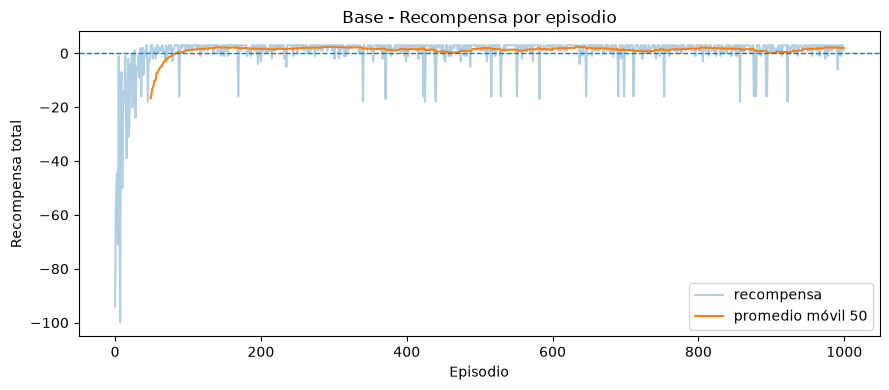

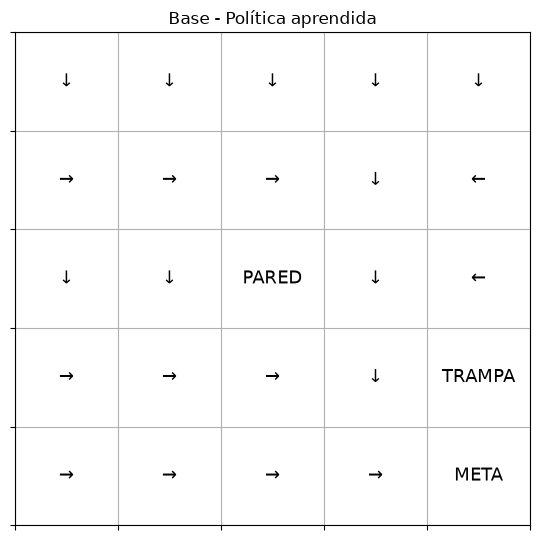

In [6]:
base = run_experiment("Base", alpha=0.1, gamma=0.9, epsilon=0.1, episodes=1000, seed=7)

## 6. Comparación de hiperparámetros

Ejecuten al menos tres experimentos y comparen resultados.

=== Sin exploración ===
alpha=0.1, gamma=0.9, epsilon=0.0, episodes=1000, epsilon_decay=None
Recompensa promedio últimos 100 episodios: 3.00
Pasos promedio últimos 100 episodios: 8.00
     ↓       →       ↓       ↓       ←
     →       →       →       ↓       →
     ↓       ↓   PARED       ↓       ←
     →       →       →       ↓  TRAMPA
     →       →       →       →    META


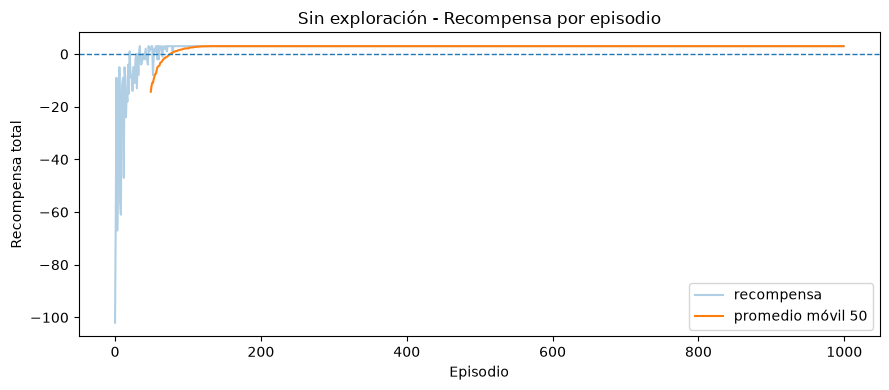

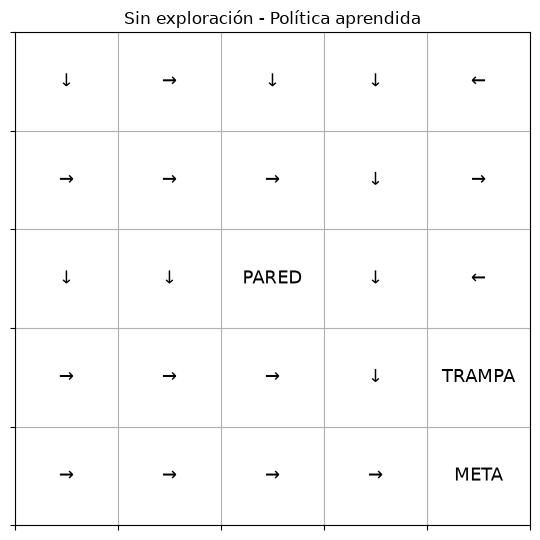

=== Exploración alta ===
alpha=0.1, gamma=0.9, epsilon=0.8, episodes=1000, epsilon_decay=None
Recompensa promedio últimos 100 episodios: -26.64
Pasos promedio últimos 100 episodios: 29.93
     ↓       ↓       ↓       ↓       ←
     ↓       ↓       →       ↓       ←
     →       ↓   PARED       ↓       ←
     →       →       →       ↓  TRAMPA
     →       →       →       →    META


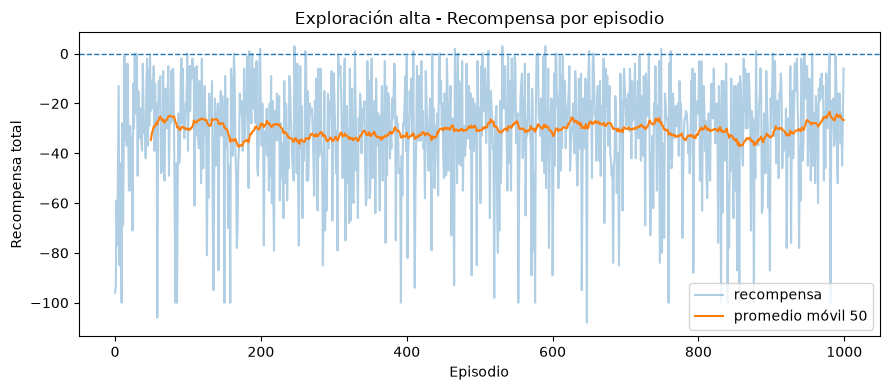

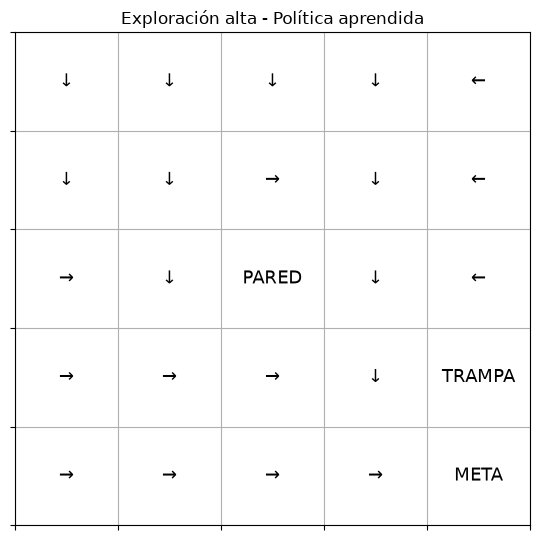

=== Futuro débil ===
alpha=0.1, gamma=0.2, epsilon=0.1, episodes=1000, epsilon_decay=None
Recompensa promedio últimos 100 episodios: 1.05
Pasos promedio últimos 100 episodios: 8.75
     →       ↓       ↓       ↓       ↑
     ↓       ↓       →       ↓       ←
     →       ↓   PARED       ↓       ←
     ↓       →       →       ↓  TRAMPA
     →       →       →       →    META


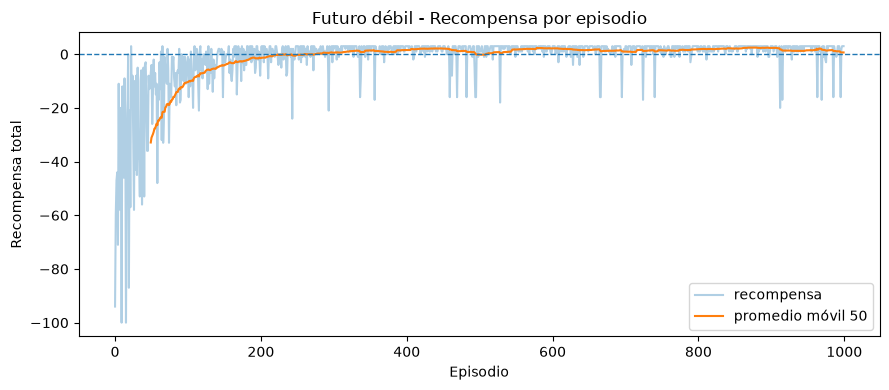

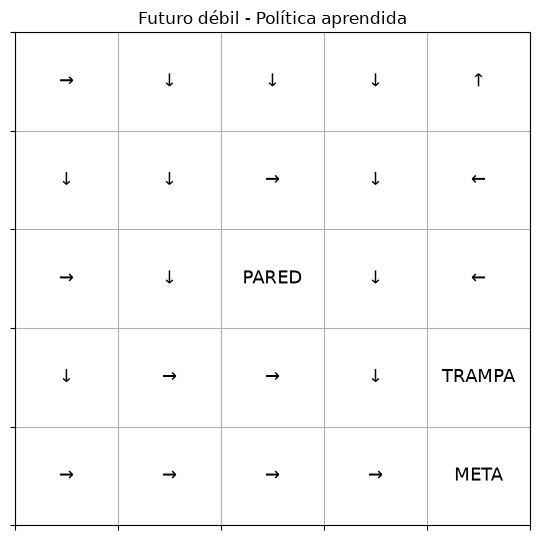

=== Aprendizaje agresivo ===
alpha=0.9, gamma=0.9, epsilon=0.1, episodes=1000, epsilon_decay=None
Recompensa promedio últimos 100 episodios: 1.83
Pasos promedio últimos 100 episodios: 8.97
     ↓       ↓       ↓       ↓       ←
     ↓       ↓       →       ↓       ←
     →       ↓   PARED       ↓       ↑
     →       ↓       ↓       ↓  TRAMPA
     →       →       →       →    META


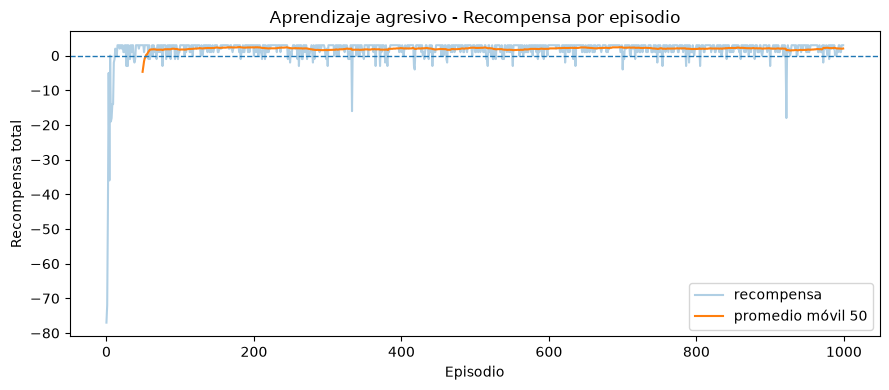

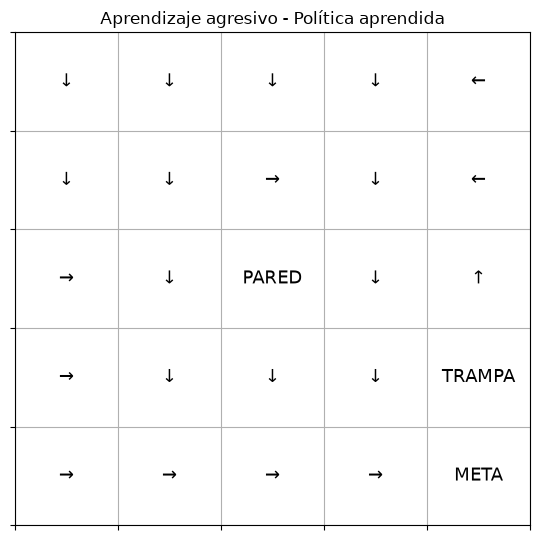

In [7]:
experiments = [
    ("Sin exploración", 0.1, 0.9, 0.0),
    ("Exploración alta", 0.1, 0.9, 0.8),
    ("Futuro débil", 0.1, 0.2, 0.1),
    ("Aprendizaje agresivo", 0.9, 0.9, 0.1),
]

results = []
for name, alpha, gamma, epsilon in experiments:
    results.append(run_experiment(name, alpha=alpha, gamma=gamma, epsilon=epsilon, episodes=1000, seed=7))

## 7. Preguntas para responder

1. ¿Dónde aparece en el código la selección de acción? ¿Qué hace epsilon-greedy?
2. ¿Dónde aparece la respuesta del entorno? Identifiquen `reward` y `next_state`.
3. ¿Dónde se actualiza Q? Expliquen la fórmula en palabras.
4. ¿Por qué epsilon-greedy no aparece dentro de la ecuación de actualización?
5. ¿Qué representa el target `reward + gamma * max(Q[next_state])`?
6. ¿Cuál fue la mejor configuración? Justifiquen con curva y política.
7. ¿Qué pasa si epsilon es 0 desde el inicio?
8. ¿Qué pasa si gamma es bajo?
9. Conclusión final: ¿cómo aprende el agente?

## Respuestas Sección 7

1. La selección de acción aparece en la línea donde se llama a `choose_action_epsilon_greedy(Q, s_idx, eps, rng)`. Epsilon-greedy explora con probabilidad epsilon y, si no explora, elige la mejor acción conocida según `Q`.

2. La respuesta del entorno aparece en `next_state, reward, done = env.step(state, action)`. Ahí se obtiene el nuevo estado, la recompensa y si el episodio terminó.

3. Q se actualiza en `Q[s_idx, action] = Q[s_idx, action] + alpha * error`. En palabras: se ajusta la estimación actual hacia un objetivo que combina recompensa inmediata y valor futuro descontado.

4. Epsilon-greedy no aparece dentro de la actualización porque solo decide qué acción probar. La ecuación de actualización corrige el valor de esa acción después de ver el resultado.

5. El target `reward + gamma * max(Q[next_state])` representa la recompensa actual más el mejor valor futuro esperado desde el nuevo estado, descontado por gamma.

6. La mejor configuración observada fue Sin exploración, con recompensa promedio de los últimos 100 episodios igual a 3.00 y 8.00 pasos promedio. Base y Aprendizaje agresivo quedaron en 1.83, Futuro débil en 1.05 y Exploración alta en -26.64.

7. Si epsilon es 0 desde el inicio, el agente siempre explota y no prueba acciones nuevas. En este experimento igual llegó a una buena política porque el entorno es pequeño y np.argmax rompe empates de forma determinista, pero en general puede quedar atrapado en una política subóptima.

8. Si gamma es bajo, el agente valora poco el futuro y aprende una política más miope. En los resultados, Futuro débil con gamma = 0.2 tuvo recompensa promedio 1.05, peor que Base y Sin exploración.

9. El agente aprende interactuando muchas veces con el entorno: elige una acción, observa la recompensa y el nuevo estado, y actualiza Q para que la política vaya favoreciendo trayectorias con mayor retorno acumulado.